In [2]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs

df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')

# 3. Filter for ISOLATED Greenhouse Gas Effects
# We use experiment_id='hist-GHG' to remove non-GHG factors
df_ghg_only = df.query("experiment_id == 'hist-GHG' & table_id == 'Amon' & variable_id == 'tas' & institution_id == 'NCAR'")

# 4. Load Data
gcs = gcsfs.GCSFileSystem(token='anon')
zstore = df_ghg_only.iloc[0].zstore # Pulling the first NCAR GHG-only store[cite: 4]
ds = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True)

# Example: Plotting the first time step of the temperature data
# ds.tas.isel(time=0).plot()

I0505 11:11:29.441970  130872 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0505 11:11:29.456223  130888 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)


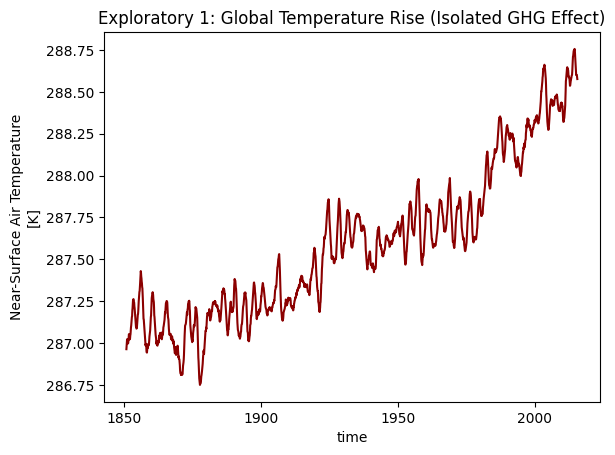

In [4]:
weights = np.cos(np.deg2rad(ds.lat))
ghg_ts = ds.tas.weighted(weights).mean(dim=['lat', 'lon'])
ghg_ts.rolling(time=12).mean().plot(color='darkred')
plt.title("Exploratory 1: Global Temperature Rise (Isolated GHG Effect)")
plt.show()



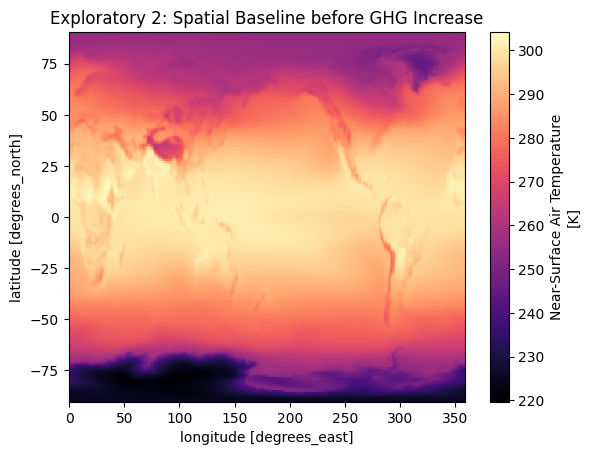

In [5]:
baseline = ds.tas.sel(time=slice("1850", "1880")).mean(dim="time")
baseline.plot(cmap='magma')
plt.title("Exploratory 2: Spatial Baseline before GHG Increase")
plt.show()

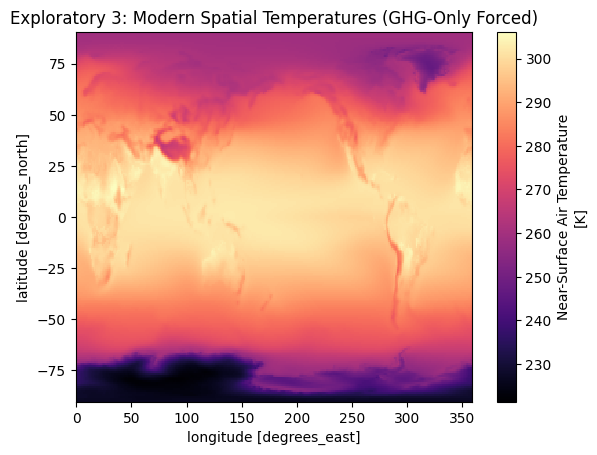

In [6]:
modern = ds.tas.sel(time=slice("2000", "2014")).mean(dim="time")
modern.plot(cmap='magma')
plt.title("Exploratory 3: Modern Spatial Temperatures (GHG-Only Forced)")
plt.show()

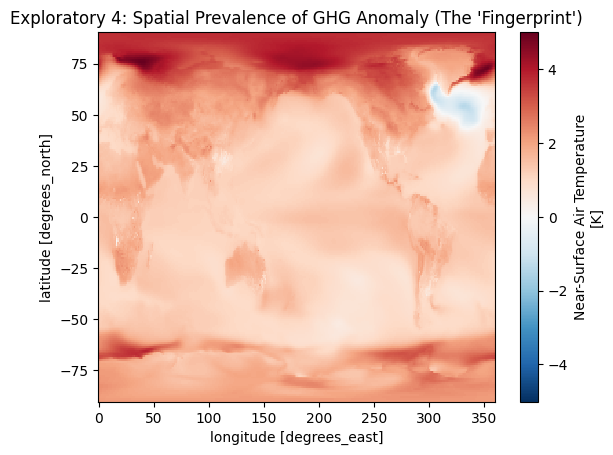

In [7]:
anomaly = modern - baseline
anomaly.plot(cmap='RdBu_r', center=0)
plt.title("Exploratory 4: Spatial Prevalence of GHG Anomaly (The 'Fingerprint')")
plt.show()

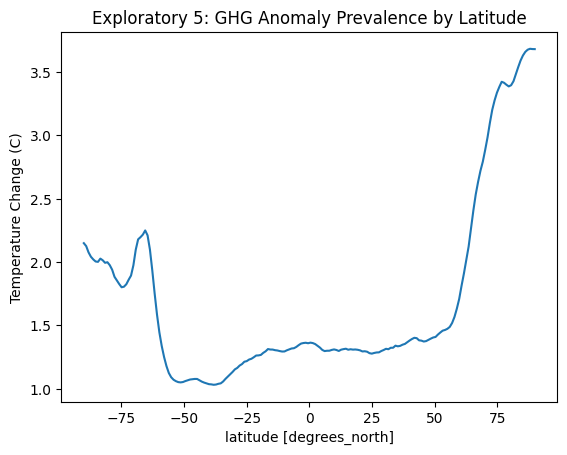

In [8]:
anomaly.mean(dim='lon').plot()
plt.title("Exploratory 5: GHG Anomaly Prevalence by Latitude")
plt.ylabel("Temperature Change (C)")
plt.show()

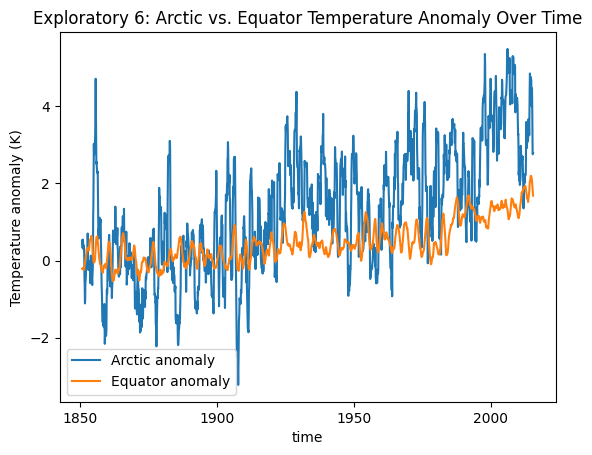

In [12]:
arctic = ds.tas.sel(lat=82, lon=0, method='nearest')
equator = ds.tas.sel(lat=0, lon=0, method='nearest')

arctic_base = arctic.sel(time=slice("1850", "1880")).mean()
equator_base = equator.sel(time=slice("1850", "1880")).mean()

(arctic - arctic_base).rolling(time=12).mean().plot(label='Arctic anomaly')
(equator - equator_base).rolling(time=12).mean().plot(label='Equator anomaly')

plt.legend()
plt.title("Exploratory 6: Arctic vs. Equator Temperature Anomaly Over Time")
plt.ylabel("Temperature anomaly (K)")
plt.show()

In [10]:
small_data = anomaly.coarsen(lat=4, lon=4, boundary="trim").mean()
small_data.to_dataframe(name="anomaly").reset_index().to_csv("ghg_only_anomaly.csv", index=False)
print("GHG-only data exported successfully.")

GHG-only data exported successfully.
